In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/sales_clean.csv", low_memory=False)

df["order_date"] = pd.to_datetime(df["order_date"])

In [3]:
# Customer-Level Metrics
customer_summary = (
    df.groupby("cust_id")
      .agg(
          Total_Revenue=("Sales", "sum"),
          Total_Orders=("order_id", "nunique"),
          First_Purchase=("order_date", "min"),
          Last_Purchase=("order_date", "max")
      )
)

In [4]:
customer_summary["Customer_Lifetime_Days"] = (
    customer_summary["Last_Purchase"] -
    customer_summary["First_Purchase"]
).dt.days + 1

**AVERAGE ORDER VALUE(AOV)**

In [5]:
customer_summary["AOV"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Total_Orders"]
)

**PURCHASE FREQUENCY**

In [6]:
purchase_frequency = (
    customer_summary["Total_Orders"].sum() /
    customer_summary.shape[0]
)

print("Purchase Frequency:", round(purchase_frequency, 2))

Purchase Frequency: 2.2


**Customer Lifetime Value (CLTV)**

In [7]:
# AOV × Total Orders = Total Revenue
customer_summary["CLTV"] = (
    customer_summary["AOV"] *
    customer_summary["Total_Orders"]
)

**Customer Segmentation**

In [8]:
customer_summary["Customer_Segment"] = pd.qcut(
    customer_summary["CLTV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)
customer_summary.head()

,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Customer_Lifetime_Days,AOV,CLTV,Customer_Segment
cust_id,,,,,,,,
4,57632.00,15,2020-12-06,2021-09-14,283,3842.133333,57632.00,High Value
15,415.10,3,2020-10-08,2021-02-11,127,138.366667,415.10,Medium Value
20,50057.20,6,2021-03-20,2021-07-29,132,8342.866667,50057.20,High Value
21,126.00,1,2021-02-03,2021-02-03,1,126.000000,126.00,Low Value
23,786.48,2,2021-02-23,2021-08-07,166,393.240000,786.48,Medium Value


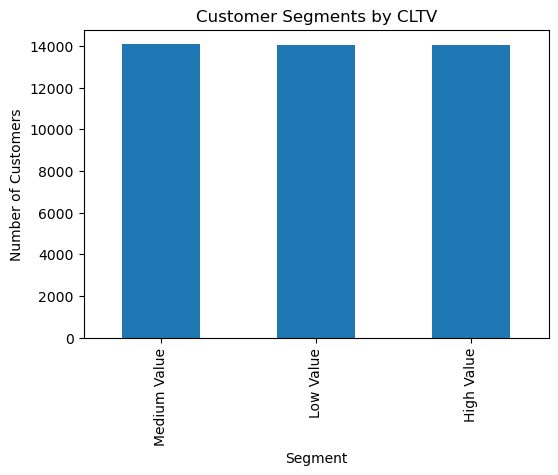

In [9]:
plt.figure(figsize=(6,4))

customer_summary["Customer_Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments by CLTV")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

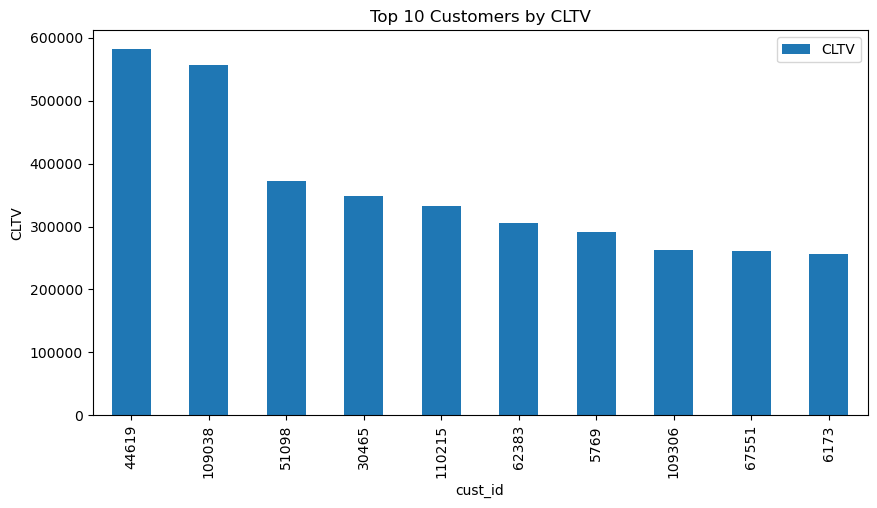

In [10]:
top_customers = customer_summary.sort_values(
    "CLTV",
    ascending=False
).head(10)

top_customers[["CLTV"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by CLTV")
plt.ylabel("CLTV")

plt.show()